In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy import stats
import numpy as np

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
})

In [3]:
df = pd.read_csv("rover_drives.csv")
len(df)
df["detour_ratio"].min()
df = df.dropna(subset=["detour_ratio"])
len(df)

535

In [4]:
d = df[(df.path_m >= 5) & (df.straight_m >= 5)].copy()
len(d)

464

In [5]:
## DETOUR IN COMPARISON TO AVG ( 1 is straight line )

(d.detour_ratio < 1.0).sum()
d.detour_ratio.median()
d.detour_ratio.quantile([.25, .5, .75])

0.25    1.030050
0.50    1.099635
0.75    1.281887
Name: detour_ratio, dtype: float64

In [6]:
### MEDIAN METERS EXTRA
d.excess_m.median()

np.float64(5.295367209144574)

In [7]:
### TOTAL EXTRA
d.excess_m.sum()

np.float64(5659.300685340901)

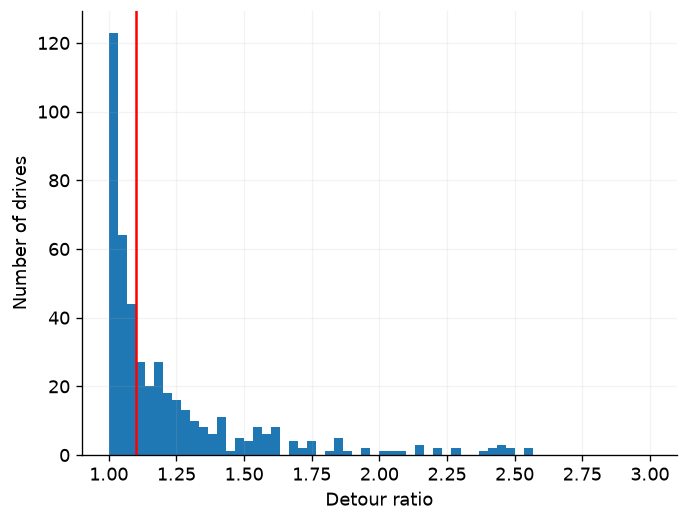

In [8]:
plt.hist(d.detour_ratio, bins=60, range=(1, 3))
plt.axvline(d.detour_ratio.median(), color="red")
plt.xlabel("Detour ratio")
plt.ylabel("Number of drives")
plt.show()

In [9]:
d[d.detour_ratio < 1.02].n_segments.value_counts()

n_segments
1    77
3     3
2     2
Name: count, dtype: int64

In [10]:
### near straight drives median

d[d.detour_ratio < 1.02].path_m.median()

np.float64(95.453)

In [11]:
### wandering drives median

d[d.detour_ratio >= 1.02].path_m.median()

np.float64(57.4055)

In [12]:
r = stats.linregress(np.log(d.straight_m), np.log(d.path_m))
print(r.slope, r.pvalue, r.rvalue**2, r.stderr)

0.9155486781073129 2.86898575470803e-310 0.9536404850067424 0.00939155603475683


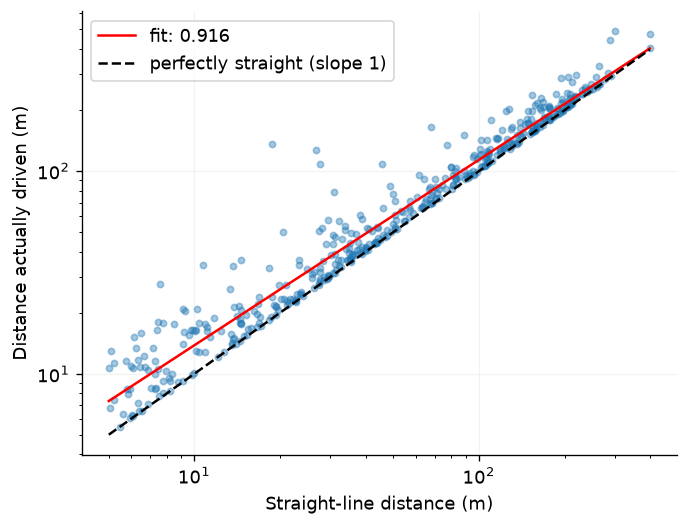

In [13]:
### but is a mathematical feature -- testing excess against path

plt.scatter(d.straight_m, d.path_m, s=14, alpha=0.4)
x = np.linspace(d.straight_m.min(), d.straight_m.max(), 100)
plt.plot(x, np.exp(r.intercept) * x**r.slope, color="red", label=f"fit: {r.slope:.3f}")
plt.plot(x, x, "--", color="black", label="perfectly straight (slope 1)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Straight-line distance (m)")
plt.ylabel("Distance actually driven (m)")
plt.legend()

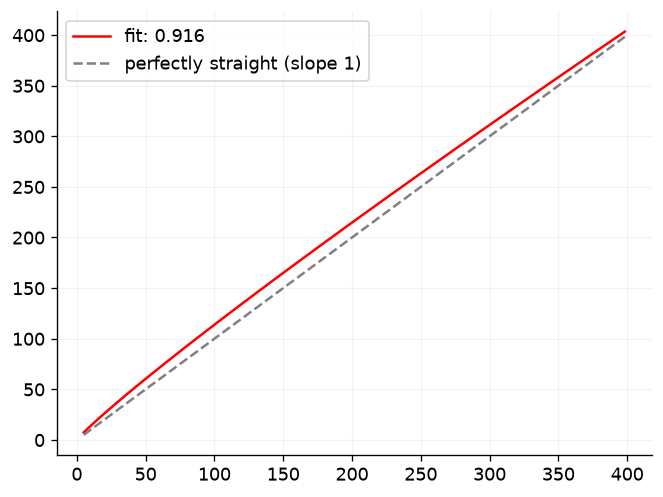

In [14]:
x = np.linspace(d.straight_m.min(), d.straight_m.max(), 100)
plt.plot(x, np.exp(r.intercept) * x**r.slope, color="red", label=f"fit: {r.slope:.3f}")
plt.plot(x, x, "--", color="gray", label="perfectly straight (slope 1)")
plt.legend()

In [15]:
### findings so far point to percentage same / relative no matter what

stats.linregress(d.tilt_mean, d.detour_ratio)
stats.linregress(d.tilt_max, d.detour_ratio)

r = stats.linregress(d.tilt_max, d.detour_ratio)
print(r.slope, r.pvalue, r.rvalue)

### tilt has no correlation

0.007090673115658939 0.0996257660282974 0.07653904428636801


Text(0, 0.5, 'Detour Ratio')

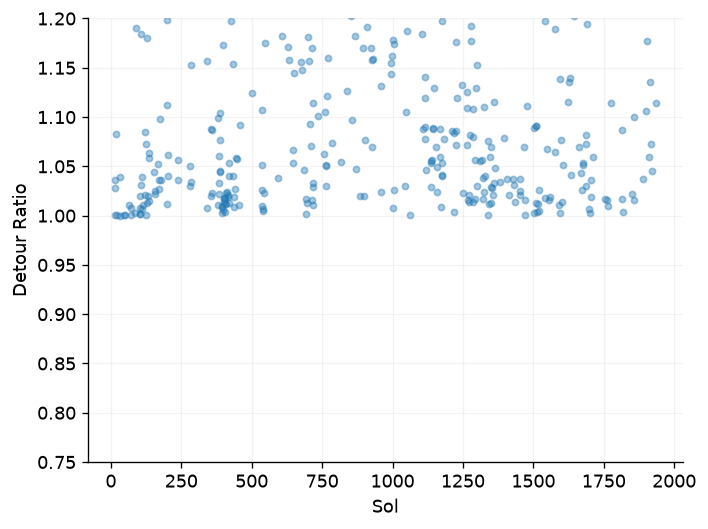

In [16]:
plt.scatter(d.sol_start, d.detour_ratio, s=14, alpha=0.4)
plt.ylim(0.75, 1.2)
plt.xlabel("Sol")
plt.ylabel("Detour Ratio")


In [17]:
m = d[d.n_segments > 1]
len(m)

118

In [18]:
m.wander_ratio.describe()

count    118.000000
mean       1.131029
std        0.214099
min        1.000018
25%        1.004308
50%        1.025530
75%        1.152561
max        2.136312
Name: wander_ratio, dtype: float64

In [19]:
stats.linregress(m.wander_ratio, m.detour_ratio)

LinregressResult(slope=np.float64(1.24787796238686), intercept=np.float64(-0.10099340186120842), rvalue=np.float64(0.7703638936279981), pvalue=np.float64(2.0302546057831757e-24), stderr=np.float64(0.09589557333371335), intercept_stderr=np.float64(0.1103706112256854))

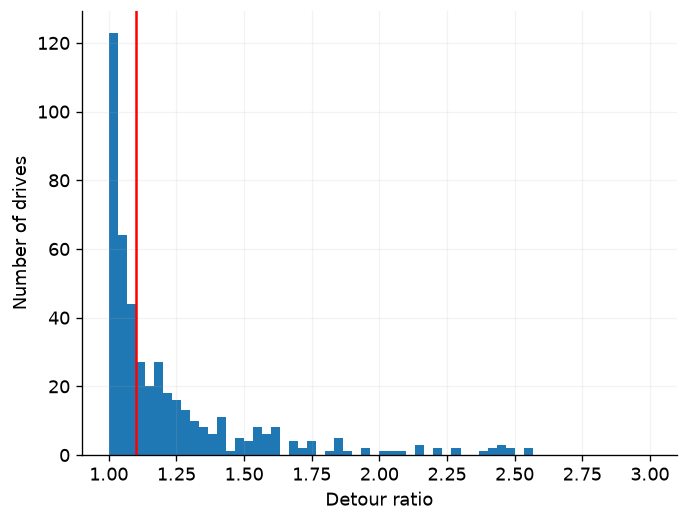

In [20]:
### DETOUR HISTO

plt.hist(d.detour_ratio, bins=60, range=(1, 3))
plt.axvline(d.detour_ratio.median(), color="red")
plt.xlabel("Detour ratio")
plt.ylabel("Number of drives")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


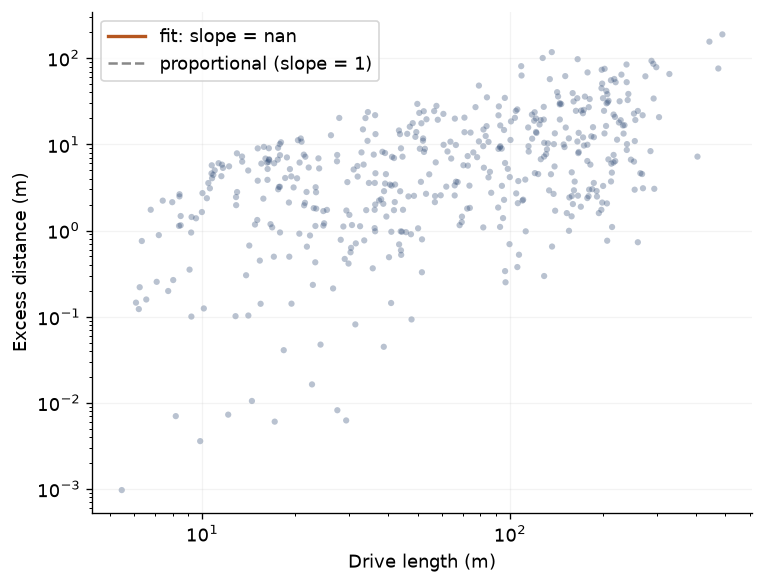

463

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5))

ax.scatter(d.path_m, d.excess_m, s=14, alpha=0.35,
           color="#37527a", edgecolors="none")

x = np.linspace(d.path_m.min(), d.path_m.max(), 100)
r = stats.linregress(np.log(d.path_m), np.log(d.excess_m))
d = df[(df.path_m >= 5) & (df.straight_m >= 5) & (df.excess_m > 0)].copy()

ax.plot(x, np.exp(r.intercept) * x**r.slope, color="#b5561f", lw=2,
        label=f"fit: slope = {r.slope:.2f}")
ax.plot(x, np.exp(r.intercept) * x**1.0, "--", color="#888", lw=1.5,
        label="proportional (slope = 1)")
ax.legend()

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Drive length (m)")
ax.set_ylabel("Excess distance (m)")

plt.tight_layout()
plt.savefig("scaling.png", dpi=200)
plt.show()

np.isinf(np.log(d.excess_m)).sum()   # should be 0
len(d)                                # 464 → 463

            n    detour    length
b                                
(0, 3]    115  1.059410   81.8080
(3, 6]     91  1.100901   91.8040
(6, 7]     26  1.129051   71.9750
(7, 8]     25  1.206139   56.9740
(8, 9]     26  1.086164   74.1490
(9, 10]    23  1.124472  117.7740
(10, 11]   21  1.098393   79.0790
(11, 12]   24  1.071686   55.0465
(12, 21]  112  1.115294   37.2780


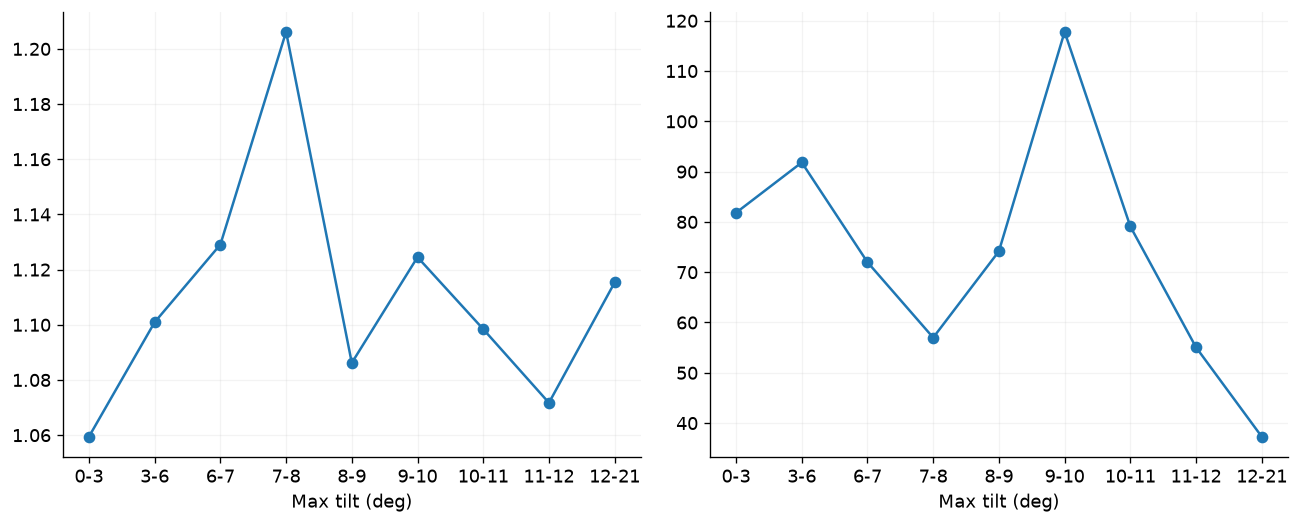

In [22]:
d["b"] = pd.cut(d.tilt_max, [0,3,6, 7, 8, 9, 10, 11, 12,21])
g = d.groupby("b", observed=True).agg(
    n=("detour_ratio","size"),
    detour=("detour_ratio","median"),
    length=("path_m","median"))
print(g)

# now plot
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

labels = [str(i).strip("()[] ").replace(", ", "-") for i in g.index]

for a in ax:
    a.set_xticks(range(len(g)))
    a.set_xticklabels(labels)
    a.set_xlabel("Max tilt (deg)")

ax[0].plot(range(len(g)), g.detour, "o-")
ax[1].plot(range(len(g)), g.length, "o-")

plt.tight_layout()
plt.savefig("terrain.png", dpi=200)
plt.show()

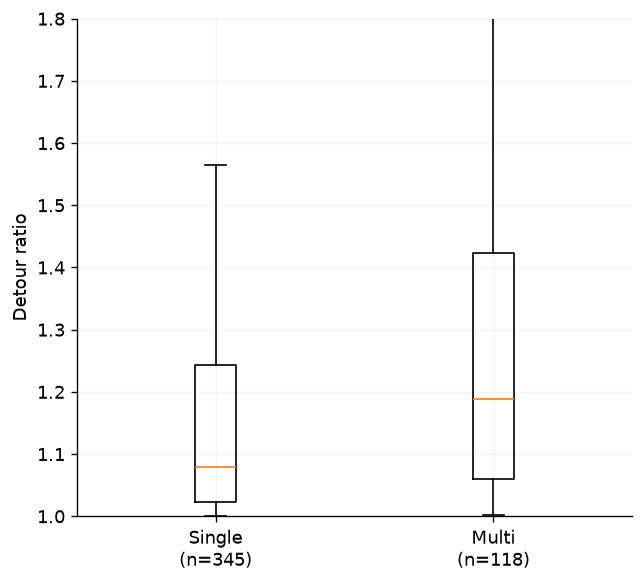

In [23]:
fig, ax = plt.subplots(figsize=(5.5, 5))

single = d[d.n_segments == 1].detour_ratio
multi  = d[d.n_segments > 1].detour_ratio

ax.boxplot([single, multi], tick_labels=[
    f"Single\n(n={len(single)})", f"Multi\n(n={len(multi)})"], showfliers=False)
ax.set_ylabel("Detour ratio")
ax.set_ylim(1, 1.8)
plt.tight_layout()
plt.savefig("segments.png", dpi=200)

In [ ]:
d.excess_m.sum() / len(d.excess_m)

np.float64(12.22311174343319)

In [ ]:
straight_m / 

1       0.219854
2       0.980380
3       0.008211
4       1.795563
5       0.000973
         ...    
536    12.391578
537     2.564114
538    14.500997
539     1.742614
540     9.515428
Name: excess_m, Length: 463, dtype: float64

In [37]:
tests = [
    ("excess vs length (log-log)", np.log(d.path_m), np.log(d.excess_m)),
    ("detour vs length",           np.log(d.path_m), d.detour_ratio),
    ("detour vs mean tilt",        d.tilt_mean,      d.detour_ratio),
    ("detour vs max tilt",         d.tilt_max,       d.detour_ratio),
    ("length vs max tilt",         d.tilt_max,       np.log(d.path_m)),
    ("detour vs sol",              d.sol_start,      d.detour_ratio),
    ("straight v. dist driven",    d.straight_m,     d.path_m),
    ("straight v. dist driven (log-log)",    np.log(d.straight_m),     np.log(d.path_m))
]

for name, x, y in tests:
    r = stats.linregress(x, y)
    print(f"{name:30s} p={r.pvalue:.4f}  r2={r.rvalue**2:.3f}  ({r.rvalue**2*100:.1f}% of variance)")

print(f"\nmedian detour: {d.detour_ratio.median():.3f}")
print(f"total excess: {d.excess_m.sum():.0f} m of {d.path_m.sum():.0f} m = {100*d.excess_m.sum()/d.path_m.sum():.1f}%")

excess vs length (log-log)     p=0.0000  r2=0.290  (29.0% of variance)
detour vs length               p=0.0084  r2=0.015  (1.5% of variance)
detour vs mean tilt            p=0.1160  r2=0.005  (0.5% of variance)
detour vs max tilt             p=0.1061  r2=0.006  (0.6% of variance)
length vs max tilt             p=0.0003  r2=0.028  (2.8% of variance)
detour vs sol                  p=0.0959  r2=0.006  (0.6% of variance)
straight v. dist driven        p=0.0000  r2=0.950  (95.0% of variance)
straight v. dist driven (log-log) p=0.0000  r2=0.953  (95.3% of variance)

median detour: 1.100
total excess: 5659 m of 43402 m = 13.0%
